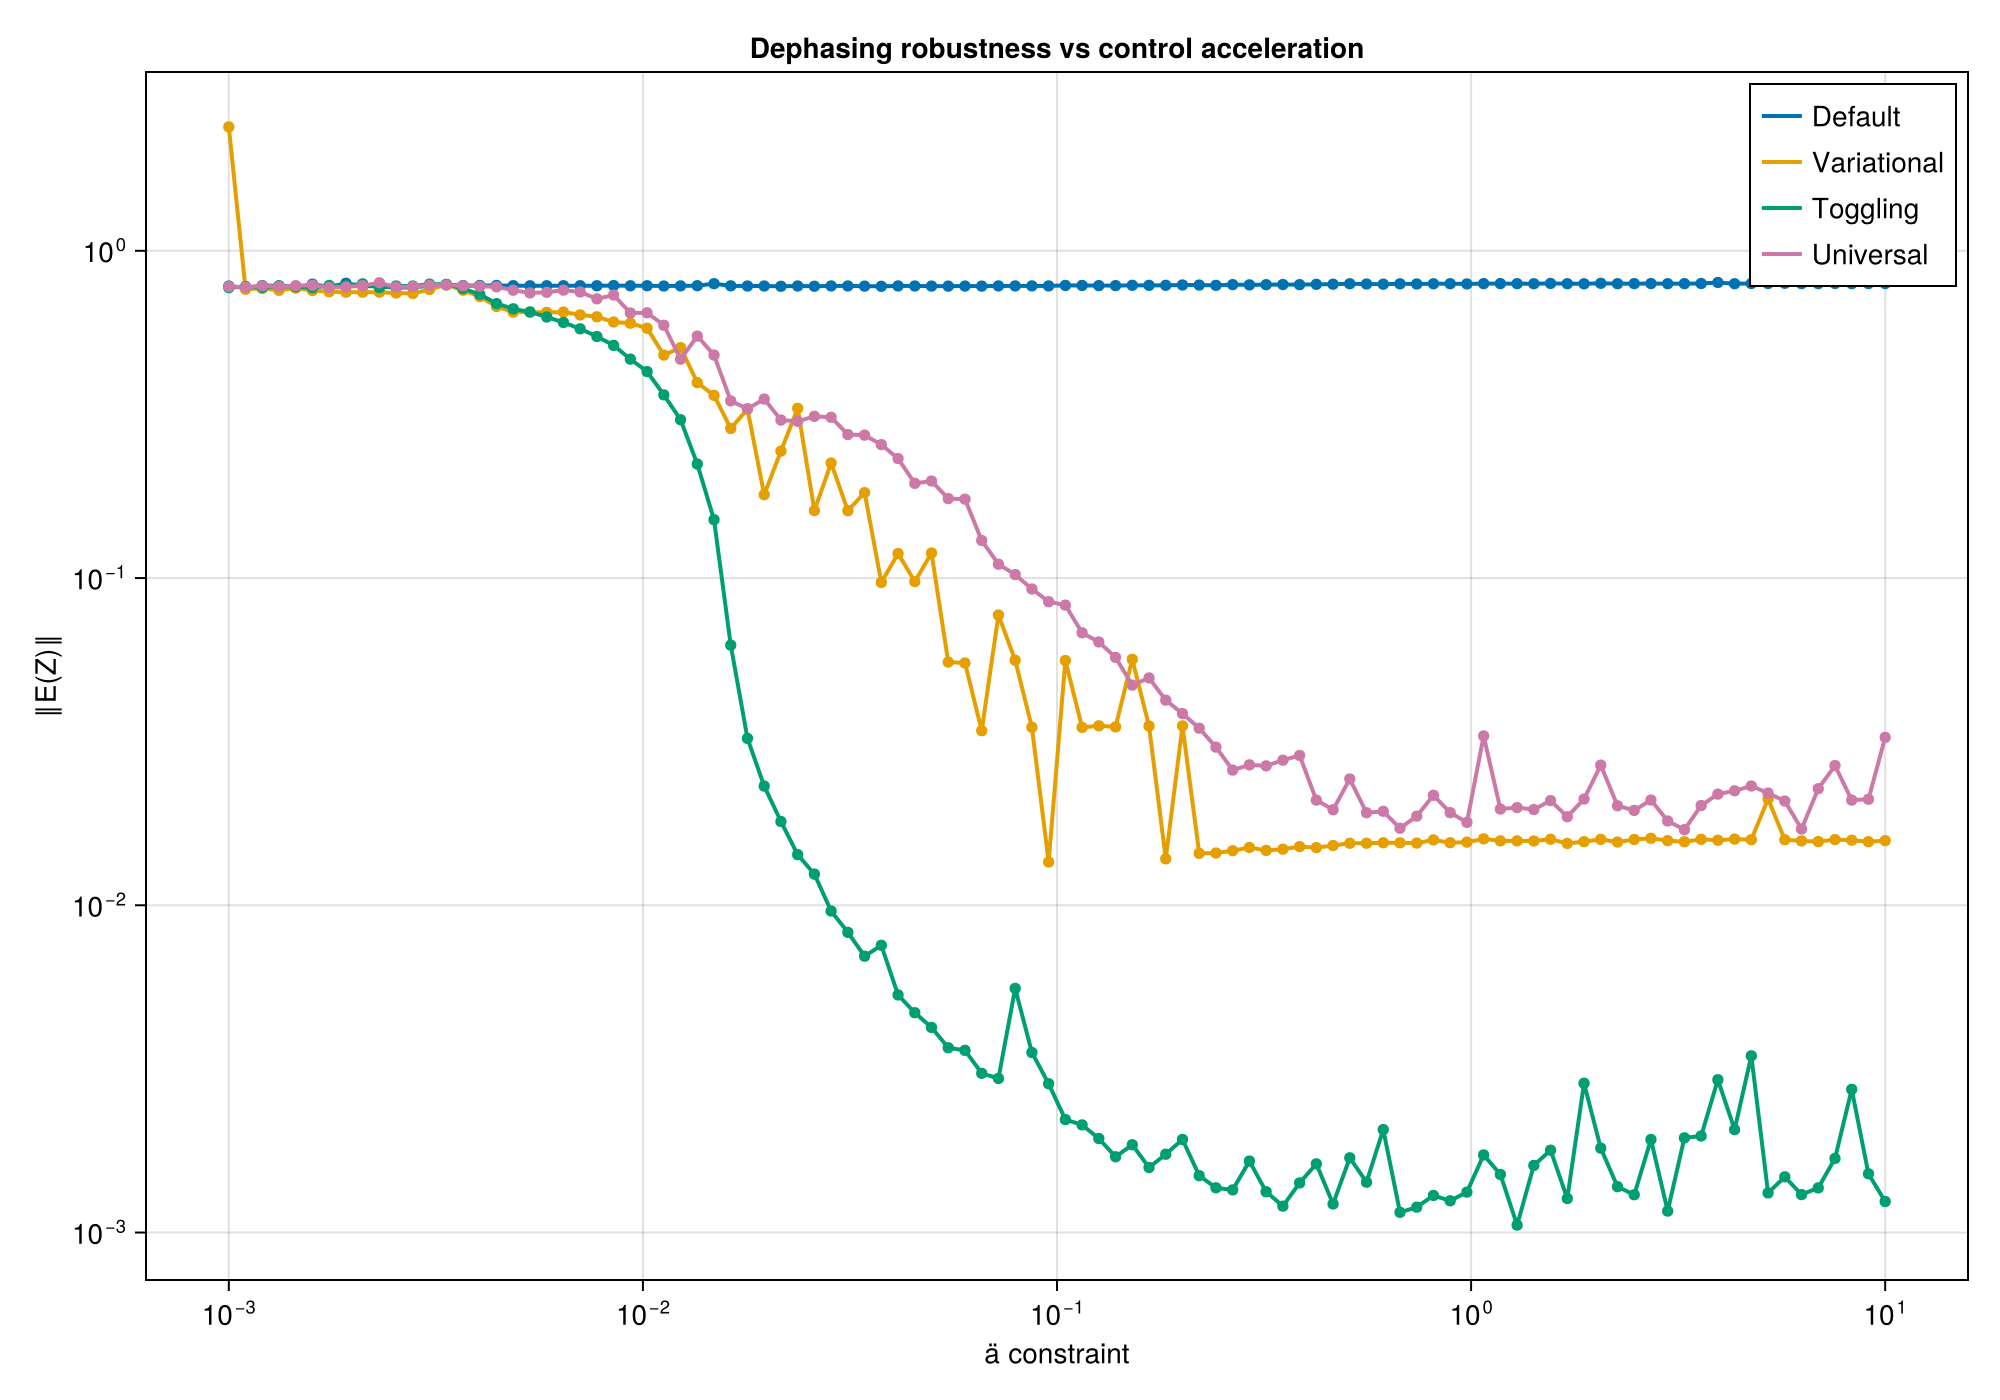

  Activating project at `~/Documents/GitHub/robust_control_sam/src`


CairoMakie.Screen{IMAGE}


In [27]:
using Pkg
Pkg.activate(".")

using CSV, DataFrames, Statistics
using CairoMakie
const CM = CairoMakie

# ---------- Load data ----------
seed_range = 1:30
dfs = DataFrame[]
for i in seed_range
    fn = "dda_constraint_uni_data_dephasing_seed_$(i).csv"
    isfile(fn) && push!(dfs, CSV.read(fn, DataFrame))
end
@assert !isempty(dfs) "No CSV files were loaded."

# x (assumed identical across files and strictly positive)
x = collect(dfs[1].ä_vals)
@assert all(isequal(x), (collect(df.ä_vals) for df in dfs))
@assert all(x .> 0)

# Stack a column across seeds into an (n_x × n_seeds) matrix
stackcol(sym) = reduce(hcat, (df[!, sym] for df in dfs))

Y_def = stackcol(:norm_G_def_z)
Y_var = stackcol(:norm_G_var_z)
Y_add = stackcol(:norm_G_add_z)
Y_uni = stackcol(:norm_G_uni_z)

# ---------- Arithmetic mean across seeds ----------
mean_def = mean(Y_def; dims=2)[:]
mean_var = mean(Y_var; dims=2)[:]
mean_add = mean(Y_add; dims=2)[:]
mean_uni = mean(Y_uni; dims=2)[:]

# ---------- Plot ----------
colors = Makie.wong_colors()
labels = ["Default", "Variational", "Toggling", "Universal"]

fig = CM.Figure(size = (1000, 700))
ax  = CM.Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "‖E(Z)‖",
    xscale = log10,
    yscale = log10,
    title  = "Dephasing robustness vs control acceleration",
)

function draw!(y, color, label)
    CM.lines!(ax, x, y; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x, y; color=color, marker=:circle, markersize=8)
end

draw!(mean_def, colors[1], labels[1])
draw!(mean_var, colors[2], labels[2])
draw!(mean_add, colors[3], labels[3])
draw!(mean_uni, colors[4], labels[4])

CM.axislegend(ax; position=:rt)
display(fig)
# save("dda_constraint_dephasing_z_means_linear.png", fig; px_per_unit=2)

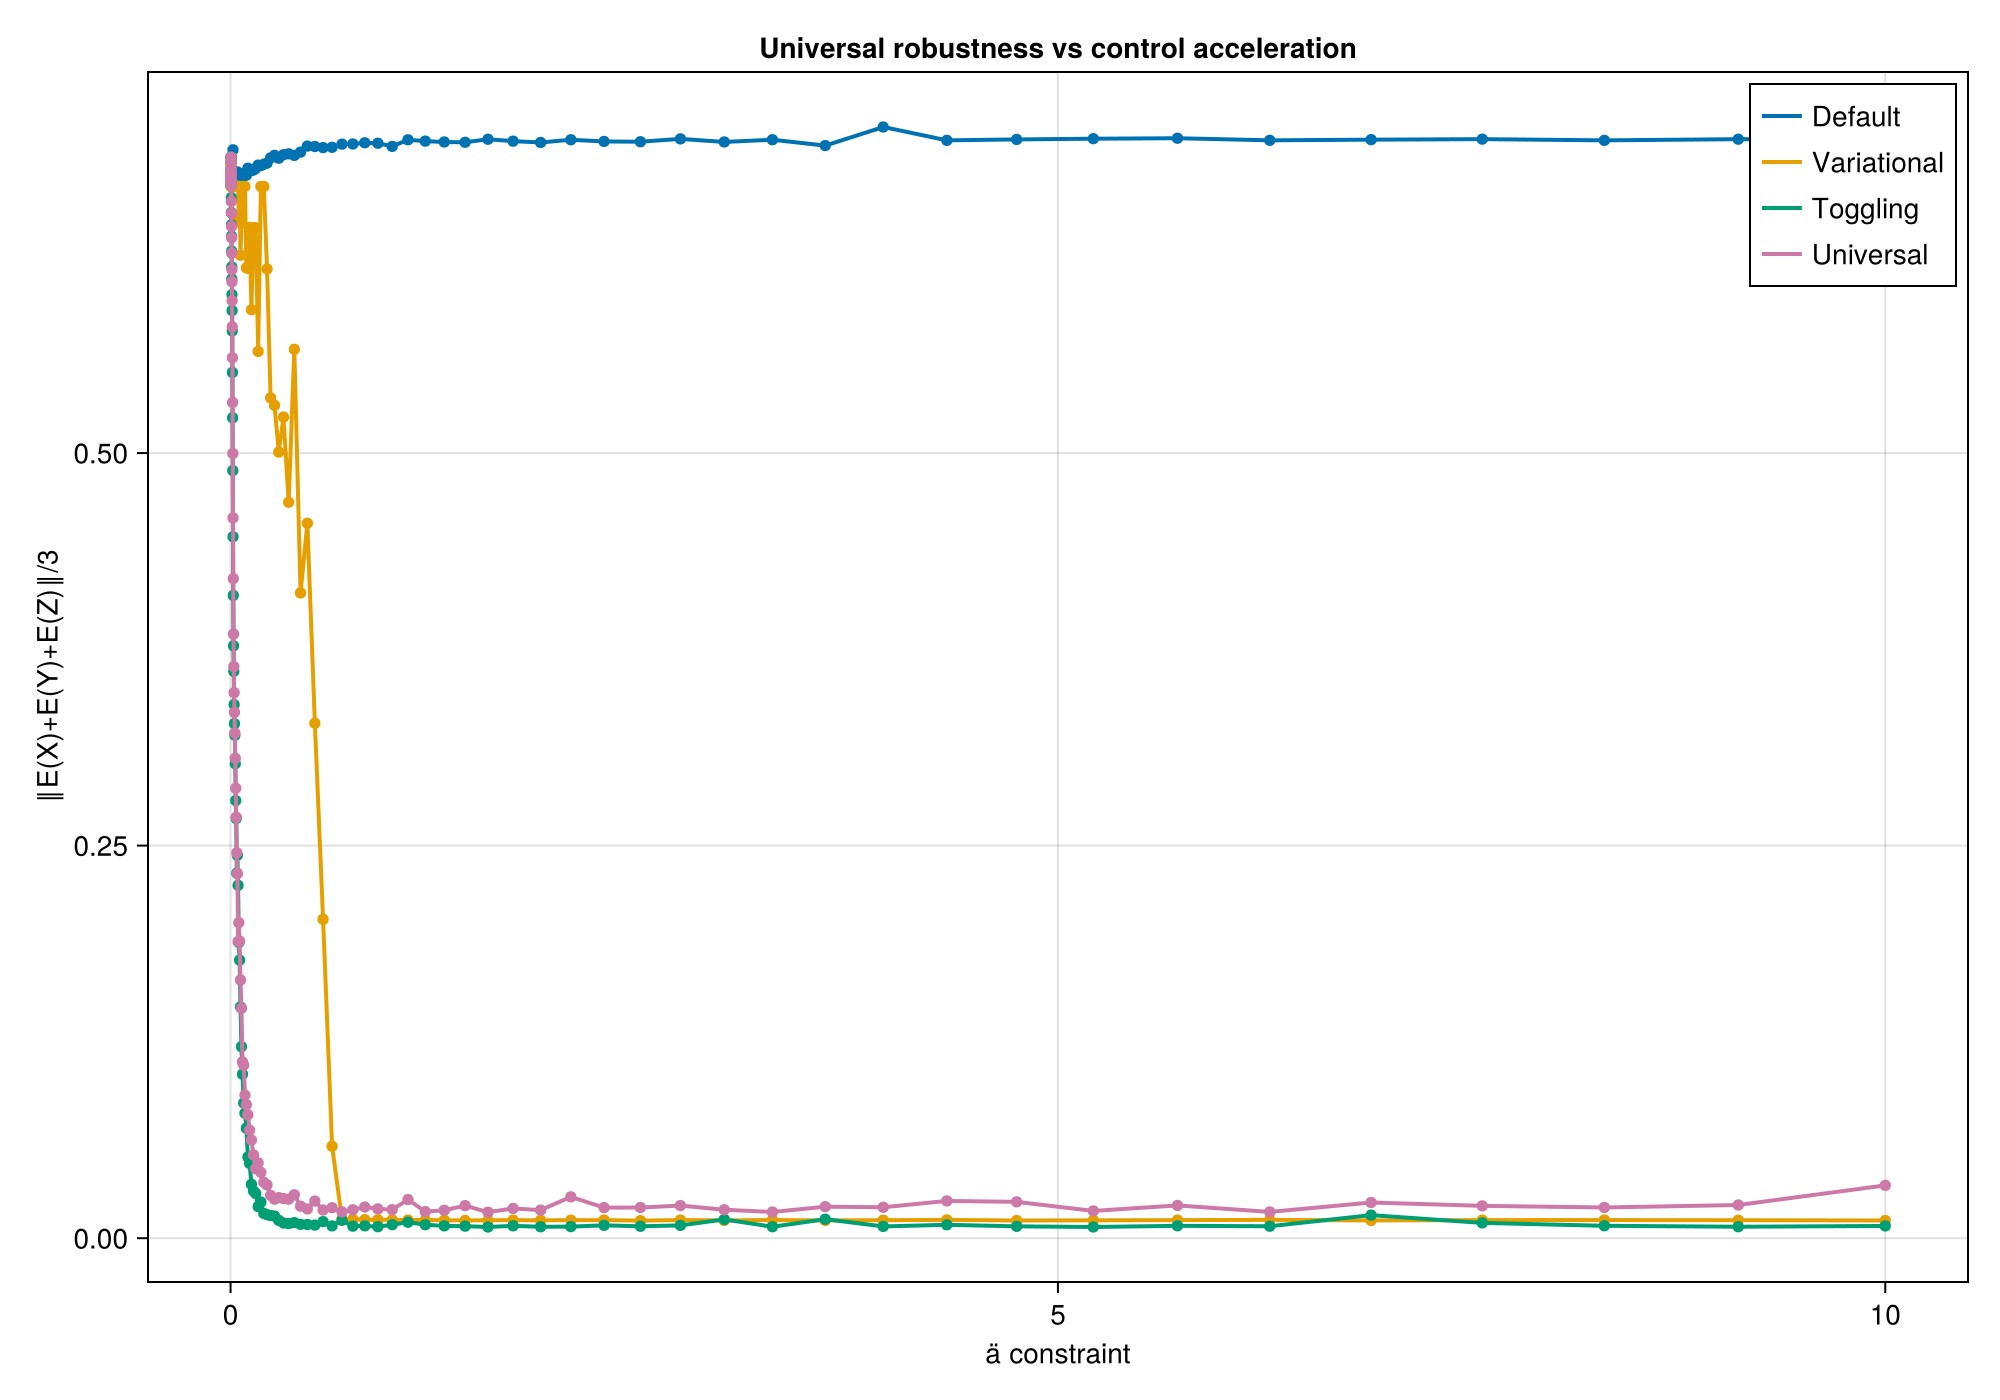

  Activating project at `~/Documents/GitHub/robust_control_sam/src`


CairoMakie.Screen{IMAGE}


In [ ]:
using Pkg
Pkg.activate(".")

using CSV, DataFrames, Statistics
using CairoMakie
const CM = CairoMakie

# ---------- Load data ----------
seed_range = 1:25
dfs = DataFrame[]
for i in seed_range
    fn = "some_more_plots+data_AK/some_data/dda_constraint_uni_data_seed_$(i).csv"
    isfile(fn) && push!(dfs, CSV.read(fn, DataFrame))
end
@assert !isempty(dfs) "No CSV files were loaded."

# x (assumed identical across files and strictly positive)
x = collect(dfs[1].ä_vals)
@assert all(isequal(x), (collect(df.ä_vals) for df in dfs))
@assert all(x .> 0)

# Stack a column across seeds into an (n_x × n_seeds) matrix
stackcol(sym) = reduce(hcat, (df[!, sym] for df in dfs))

Y_def = stackcol(:norm_G_def)
Y_var = stackcol(:norm_G_var)
Y_add = stackcol(:norm_G_add)
Y_uni = stackcol(:norm_G_uni)

# ---------- Arithmetic mean across seeds ----------
mean_def = mean(Y_def; dims=2)[:]
mean_var = mean(Y_var; dims=2)[:]
mean_add = mean(Y_add; dims=2)[:]
mean_uni = mean(Y_uni; dims=2)[:]

# ---------- Plot ----------
colors = Makie.wong_colors()
labels = ["Default", "Variational", "Toggling", "Universal"]

fig = CM.Figure(size = (1000, 700))
ax  = CM.Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "‖E(X)+E(Y)+E(Z)‖/3",
    #xscale = log10,
    #yscale = log10,
    title  = "Universal robustness vs control acceleration",
)

function draw!(y, color, label)
    CM.lines!(ax, x, y; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x, y; color=color, marker=:circle, markersize=8)
end

draw!(mean_def, colors[1], labels[1])
draw!(mean_var, colors[2], labels[2])
draw!(mean_add, colors[3], labels[3])
draw!(mean_uni, colors[4], labels[4])

CM.axislegend(ax; position=:rt)
display(fig)
# save("dda_constraint_dephasing_z_means_linear.png", fig; px_per_unit=2)

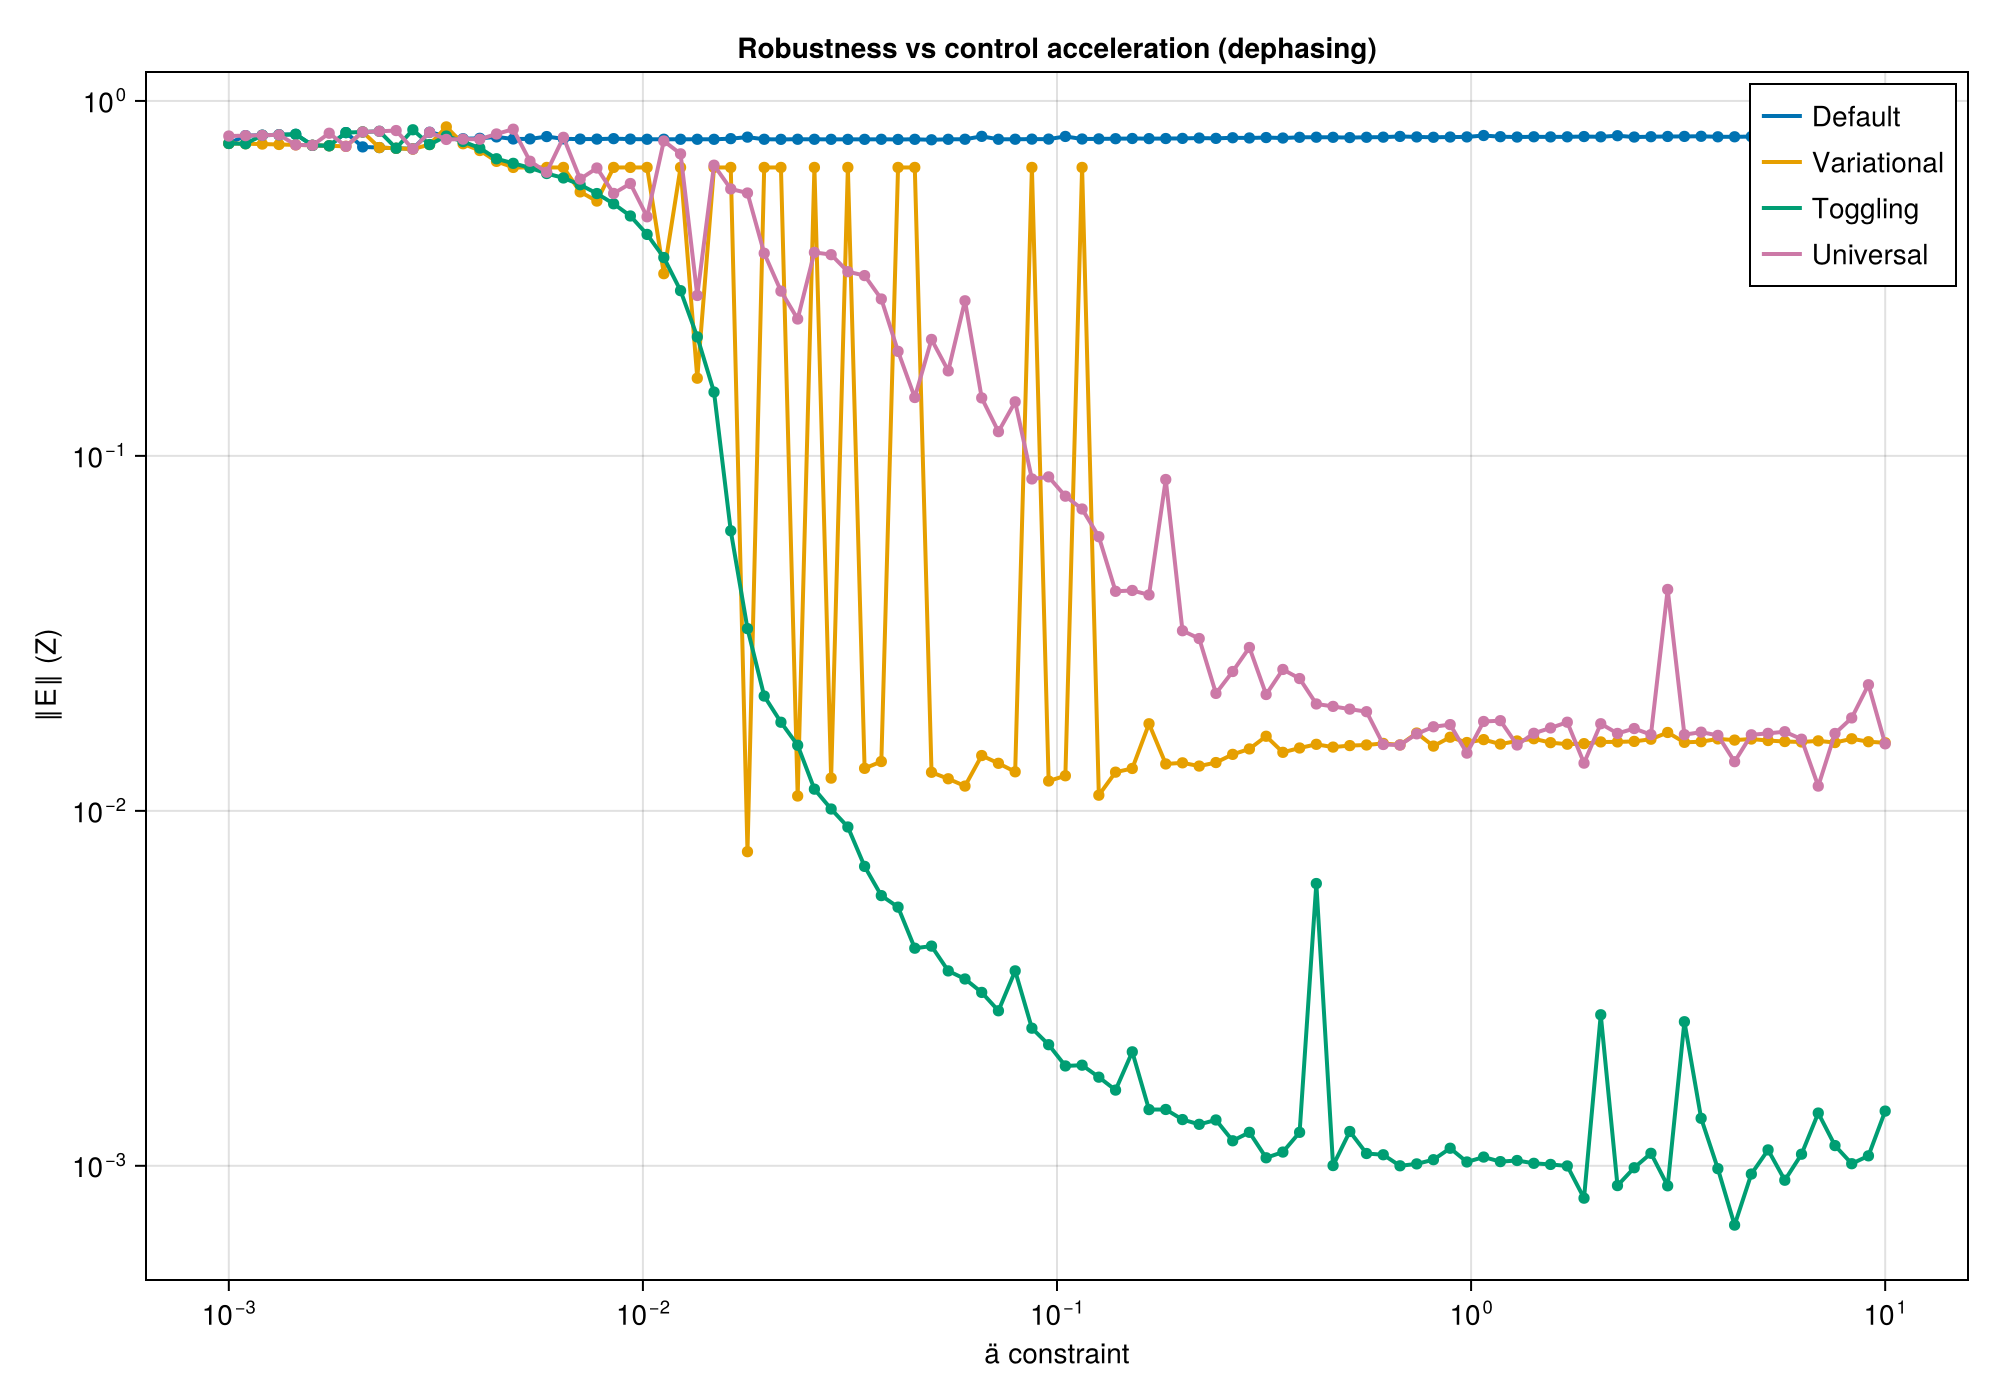

  Activating project at `~/Documents/GitHub/robust_control_sam/src`


CairoMakie.Screen{IMAGE}


In [5]:
using Pkg
Pkg.activate(".")
using CSV, DataFrames, Statistics
using CairoMakie
const CM = CairoMakie

# --- Load CSVs ---
seed_range = 1:1   # <-- right now only one file
dfs = DataFrame[]
for idx in seed_range
    fn = "dda_constraint_uni_data_dephasing_seed_$(idx).csv"
    if isfile(fn)
        push!(dfs, CSV.read(fn, DataFrame))
    else
        @warn "Missing $fn – skipping"
    end
end
@assert !isempty(dfs) "No CSV files were loaded."

# X values (assume same across files)
x = collect(dfs[1].ä_vals)
@assert all(isequal(x), (collect(df.ä_vals) for df in dfs)) "ä_vals differ across CSVs."

# Helper: stack a column across seeds into a matrix: (n_x, n_seeds)
stackcol(sym) = reduce(hcat, (df[!, sym] for df in dfs))

# Choose Z-channel (dephasing) columns (as in your snippet)
Y_def = stackcol(:norm_G_def_z)
Y_var = stackcol(:norm_G_var_z)
Y_add = stackcol(:norm_G_add_z)
Y_uni = stackcol(:norm_G_uni_z)

# --- Helpers ---
# mask rows where ALL values are > 0 (needed for log axes)
mask_log_ok(Y) = mapslices(r -> all(r .> 0), Y; dims=2)[:]

function draw_one!(ax, x, y; color, label)
    CM.lines!(ax, x, y; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x, y; color=color, marker=:circle, markersize=8)
end

function draw_many!(ax, x, Y; color, label)
    # mask rows where all seeds and x are positive
    row_ok = mask_log_ok(Y) .& (x .> 0)
    x2 = x[row_ok]
    Y2 = Y[row_ok, :]

    # geometric mean and ±1σ in log10 space
    LY = log10.(Y2)
    μL = mean(LY; dims=2)[:]     # mean in log space
    σL = std(LY;  dims=2)[:]     # std in log space

    μ  = 10 .^ μL
    lo = 10 .^ (μL .- σL)
    hi = 10 .^ (μL .+ σL)

    CM.band!(ax, x2, lo, hi; color=(color, 0.25))
    CM.lines!(ax, x2, μ; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x2, μ; color=color, marker=:circle, markersize=8)
end

colors = Makie.wong_colors()
labels = ["Default", "Variational", "Toggling", "Universal"]

fig = CM.Figure(size = (1000, 700))
ax  = CM.Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "‖E‖ (Z)",
    xscale = log10,
    yscale = log10,
    title  = "Robustness vs control acceleration (dephasing)",
)

if length(dfs) == 1
    # Single file: just plot lines + dots for each series
    # Mask out nonpositive rows to keep log scales happy
    row_ok_def = (x .> 0) .& (Y_def[:,1] .> 0)
    row_ok_var = (x .> 0) .& (Y_var[:,1] .> 0)
    row_ok_add = (x .> 0) .& (Y_add[:,1] .> 0)
    row_ok_uni = (x .> 0) .& (Y_uni[:,1] .> 0)

    draw_one!(ax, x[row_ok_def], Y_def[row_ok_def, 1]; color=colors[1], label=labels[1])
    draw_one!(ax, x[row_ok_var], Y_var[row_ok_var, 1]; color=colors[2], label=labels[2])
    draw_one!(ax, x[row_ok_add], Y_add[row_ok_add, 1]; color=colors[3], label=labels[3])
    draw_one!(ax, x[row_ok_uni], Y_uni[row_ok_uni, 1]; color=colors[4], label=labels[4])
else
    # Multiple files: draw mean curve + shaded ±σ band (in log space)
    draw_many!(ax, x, Y_def; color=colors[1], label=labels[1])
    draw_many!(ax, x, Y_var; color=colors[2], label=labels[2])
    draw_many!(ax, x, Y_add; color=colors[3], label=labels[3])
    draw_many!(ax, x, Y_uni; color=colors[4], label=labels[4])
end

CM.axislegend(ax; position = :rt)
display(fig)
# save("dda_constraint_dephasing_z_loglog.png", fig; px_per_unit=2)

Reading ZZ objective data from seed files...
Reading Z1_Z2_ZZ objective data from seed files...
Calculating statistics...

Creating stacked bar chart...


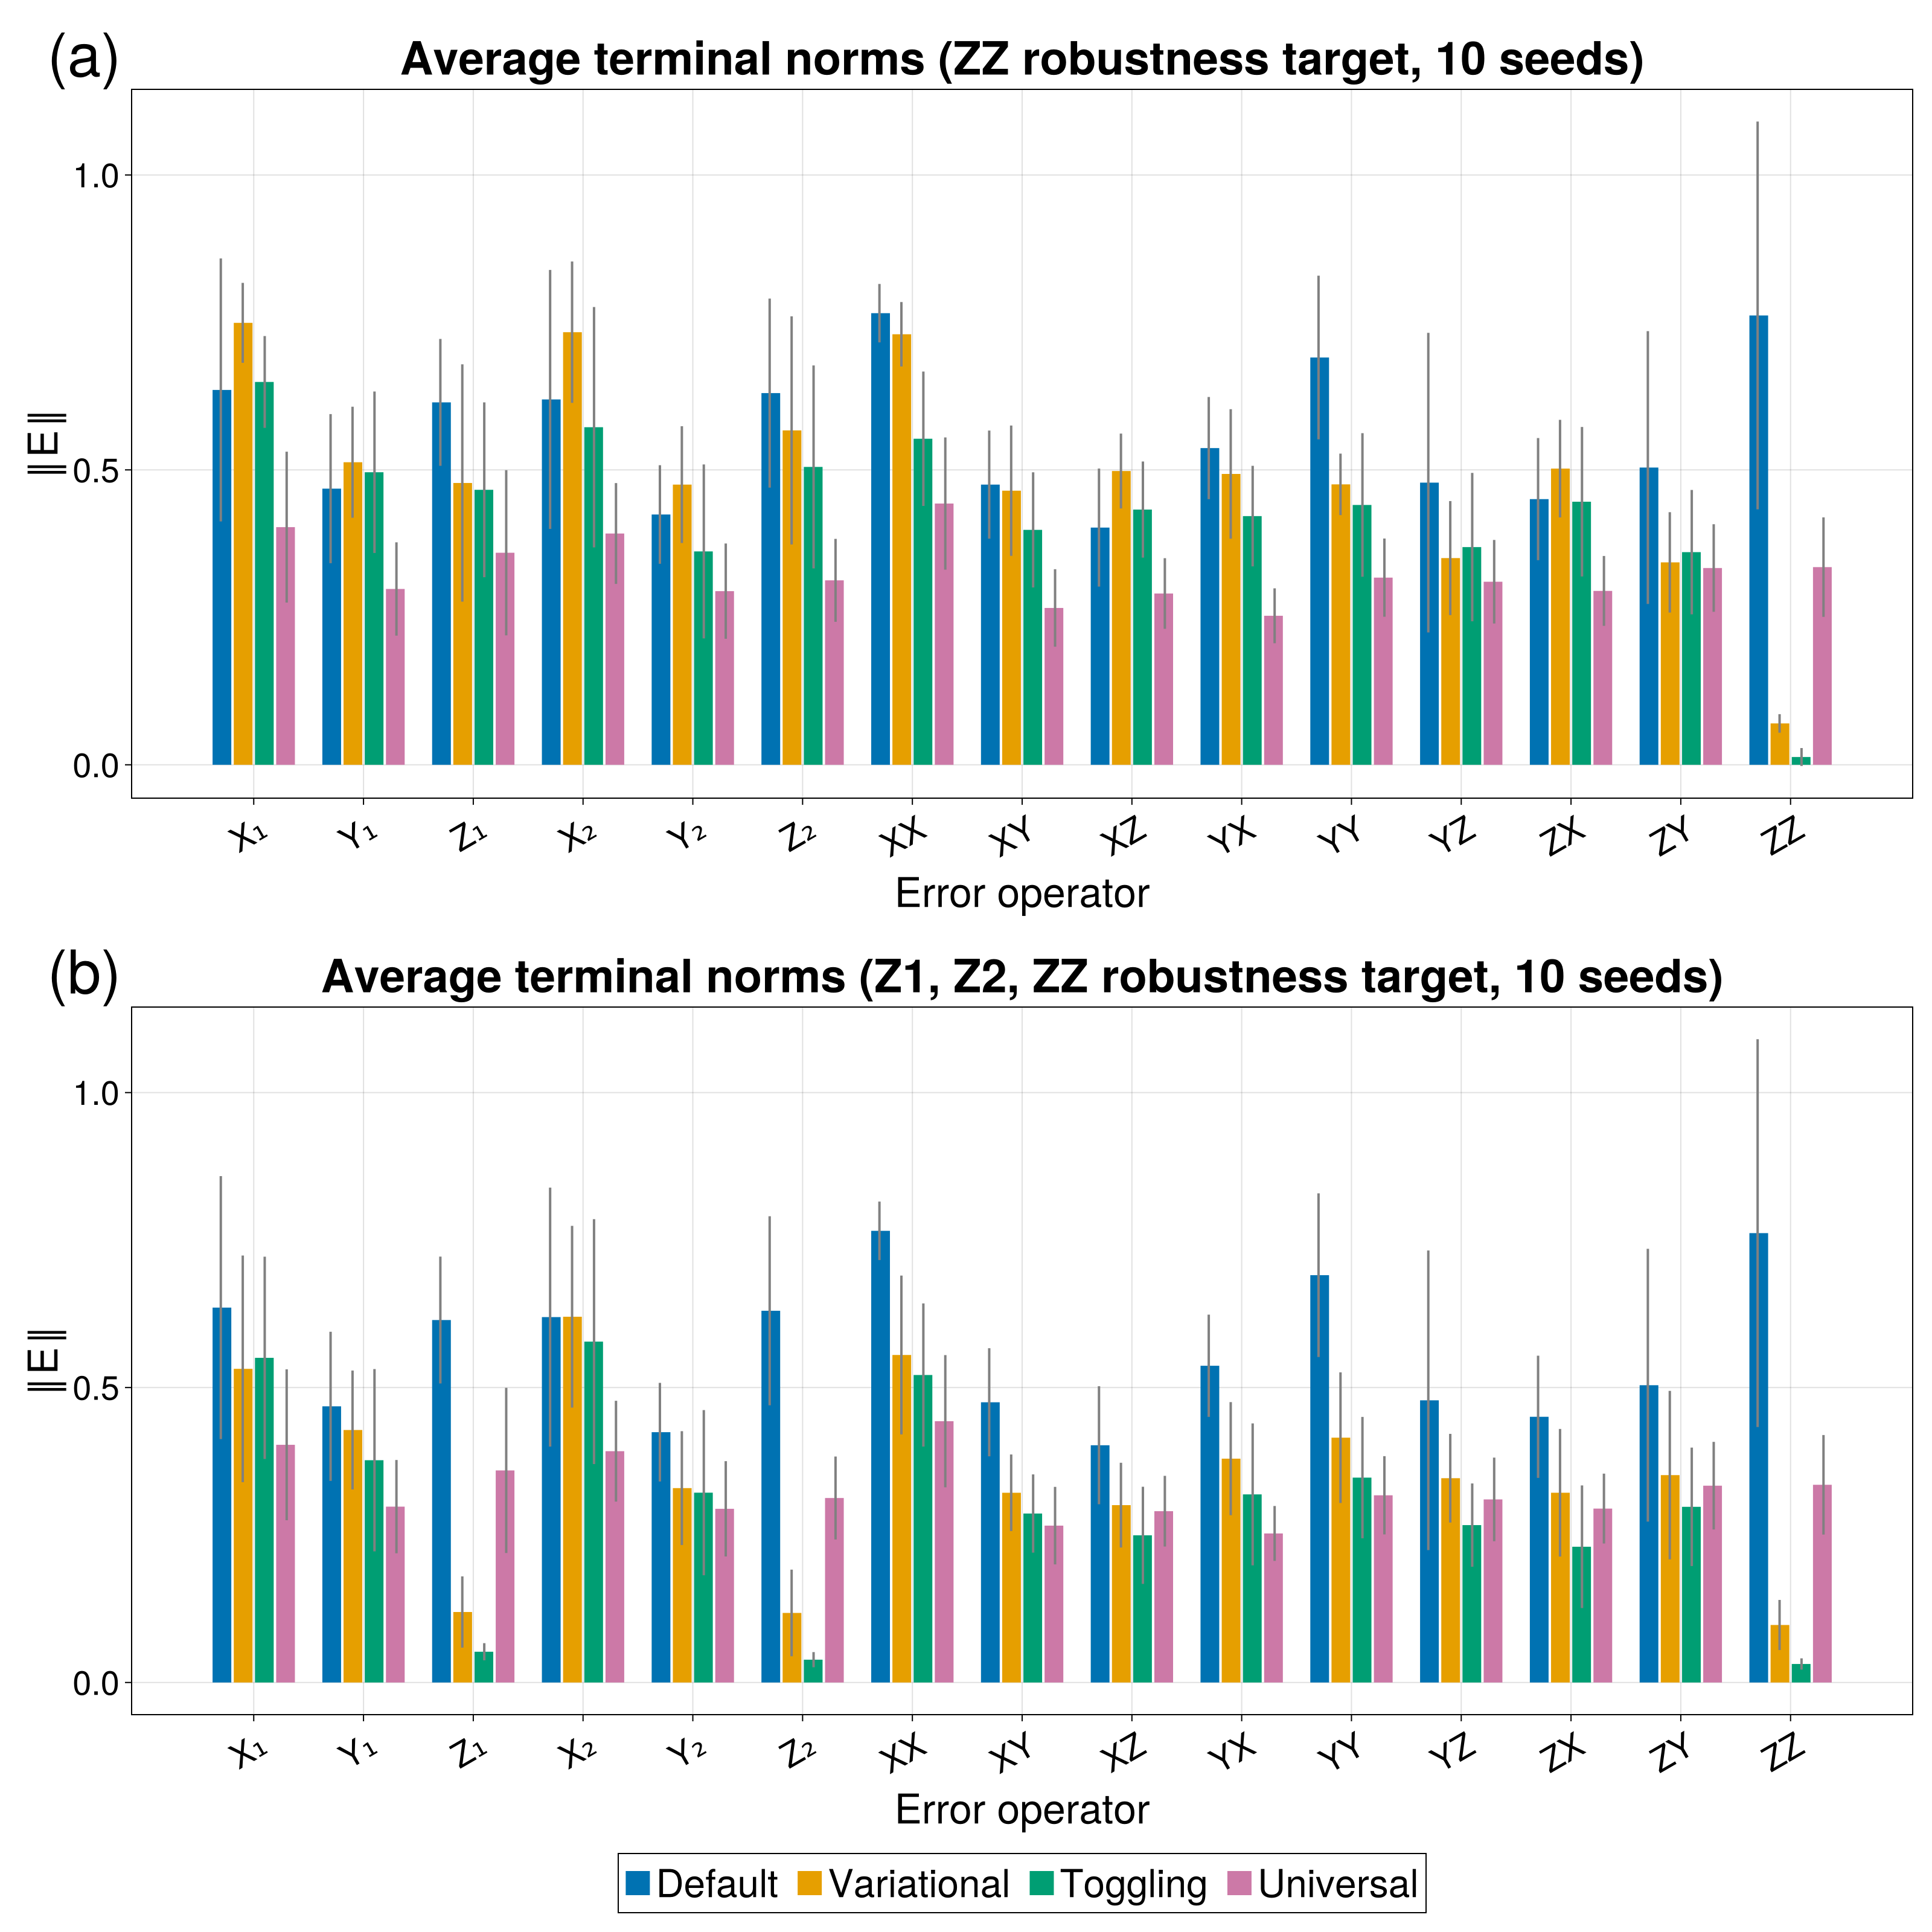

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/andrewkamen/.julia/packages/Makie/FUAHr/src/scenes.jl:238


In [31]:
using DataFrames, CSV, CairoMakie, Statistics
CM = CairoMakie

# Function to read and aggregate data from multiple seed files
function aggregate_seed_data(num_seeds::Int, file_pattern::String)
    all_data = Dict{String, Vector{Vector{Float64}}}()
    err_labels = nothing
    for seed in 1:num_seeds
        filename = replace(file_pattern, "SEED" => string(seed))
        if !isfile(filename)
            println("Warning: File $filename not found, skipping...")
            continue
        end
        try
            df = CSV.read(filename, DataFrame)
            if err_labels === nothing
                err_labels = df.Error
            end
            for method in ["Default", "Variational", "Toggling", "Universal"]
                if haskey(all_data, method)
                    push!(all_data[method], df[!, method])
                else
                    all_data[method] = [df[!, method]]
                end
            end
        catch e
            println("Error reading $filename: $e")
            continue
        end
    end
    return all_data, err_labels
end

function calculate_stats(all_data, err_labels)
    methods = ["Default", "Variational", "Toggling", "Universal"]
    n_errors = length(err_labels)
    means = Dict{String, Vector{Float64}}()
    stds  = Dict{String, Vector{Float64}}()
    for method in methods
        if haskey(all_data, method)
            data_matrix = hcat(all_data[method]...)
            means[method] = [mean(data_matrix[i, :]) for i in 1:n_errors]
            stds[method]  = [std(data_matrix[i, :]) for i in 1:n_errors]
        else
            means[method] = zeros(n_errors)
            stds[method]  = zeros(n_errors)
        end
    end
    return means, stds
end

function create_bar_subplot!(fig, row, col, means, stds, err_labels, title_text, num_seeds)
    methods = ["Default", "Variational", "Toggling", "Universal"]
    n = length(err_labels)

    y = collect(Iterators.flatten((means[m][i] for m in methods) for i in 1:n))
    yerr = collect(Iterators.flatten((stds[m][i] for m in methods) for i in 1:n))

    x = repeat(1:n, inner=4)
    g = repeat(1:4, outer=n)

    palette = Makie.wong_colors()
    series_colors = palette[1:4]
    barcolors = series_colors[g]

    ax = CM.Axis(fig[row, col];
        xticks = (1:n, err_labels),
        xticklabelrotation = π/6,
        xlabel = "Error operator",
        ylabel = "‖E‖",
        title = title_text,
        xlabelsize = 34,
        ylabelsize = 34,
        titlesize = 38,
        xticklabelsize = 28,
        yticklabelsize = 28,
    )

    CM.barplot!(ax, x, y; dodge=g, color=barcolors, gap=0.25)

    # manual dodge offsets for errorbars
    dodge_width = 0.8
    n_dodge = 4
    width = dodge_width / n_dodge
    error_x = [x[i] + (g[i] - (n_dodge+1)/2) * width for i in 1:length(x)]
    CM.errorbars!(ax, error_x, y, yerr; color=:gray, linewidth=2)

    return ax, series_colors
end

function create_stacked_bar_chart(means1, stds1, err_labels1, means2, stds2, err_labels2, num_seeds)
    methods = ["Default", "Variational", "Toggling", "Universal"]
    fig = CM.Figure(resolution=(1600, 1600), fontsize=30, padding=25)

    ax1, series_colors = create_bar_subplot!(
        fig, 1, 1, means1, stds1, err_labels1,
        "Average terminal norms (ZZ robustness target, $num_seeds seeds)", num_seeds)

    ax2, _ = create_bar_subplot!(
        fig, 2, 1, means2, stds2, err_labels2,
        "Average terminal norms (Z1, Z2, ZZ robustness target, $num_seeds seeds)", num_seeds)

    CM.Legend(fig[3, 1],
        [CM.PolyElement(color=series_colors[i]) for i in 1:4],
        methods;
        orientation=:horizontal,
        labelsize=32,
    )

    return fig
end

# Parameters
num_seeds = 10
file_pattern_zz = "terminal_spacecurve_norms_ZZ_T30_seedSEED.csv"
file_pattern_z1z2zz = "terminal_spacecurve_norms_Z1_Z2_ZZ_T30_seedSEED.csv"

println("Reading ZZ objective data from seed files...")
all_data_zz, err_labels_zz = aggregate_seed_data(num_seeds, file_pattern_zz)

println("Reading Z1_Z2_ZZ objective data from seed files...")
all_data_z1z2zz, err_labels_z1z2zz = aggregate_seed_data(num_seeds, file_pattern_z1z2zz)

if err_labels_zz !== nothing && err_labels_z1z2zz !== nothing
    println("Calculating statistics...")
    means_zz, stds_zz = calculate_stats(all_data_zz, err_labels_zz)
    means_z1z2zz, stds_z1z2zz = calculate_stats(all_data_z1z2zz, err_labels_z1z2zz)

    println("\nCreating stacked bar chart...")
    fig = create_stacked_bar_chart(
        means_zz, stds_zz, err_labels_zz,
        means_z1z2zz, stds_z1z2zz, err_labels_z1z2zz,
        num_seeds
    )

    # Panel tags (a), (b)
    CM.Label(fig[1, 1, CM.TopLeft()], "(a)"; fontsize=50, padding=(15,0,0,0), tellwidth=false)
    CM.Label(fig[2, 1, CM.TopLeft()], "(b)"; fontsize=50, padding=(15,0,0,0), tellwidth=false)

    display(fig)
    save("iswap_paper_fig.png", fig; px_per_unit=3)
end

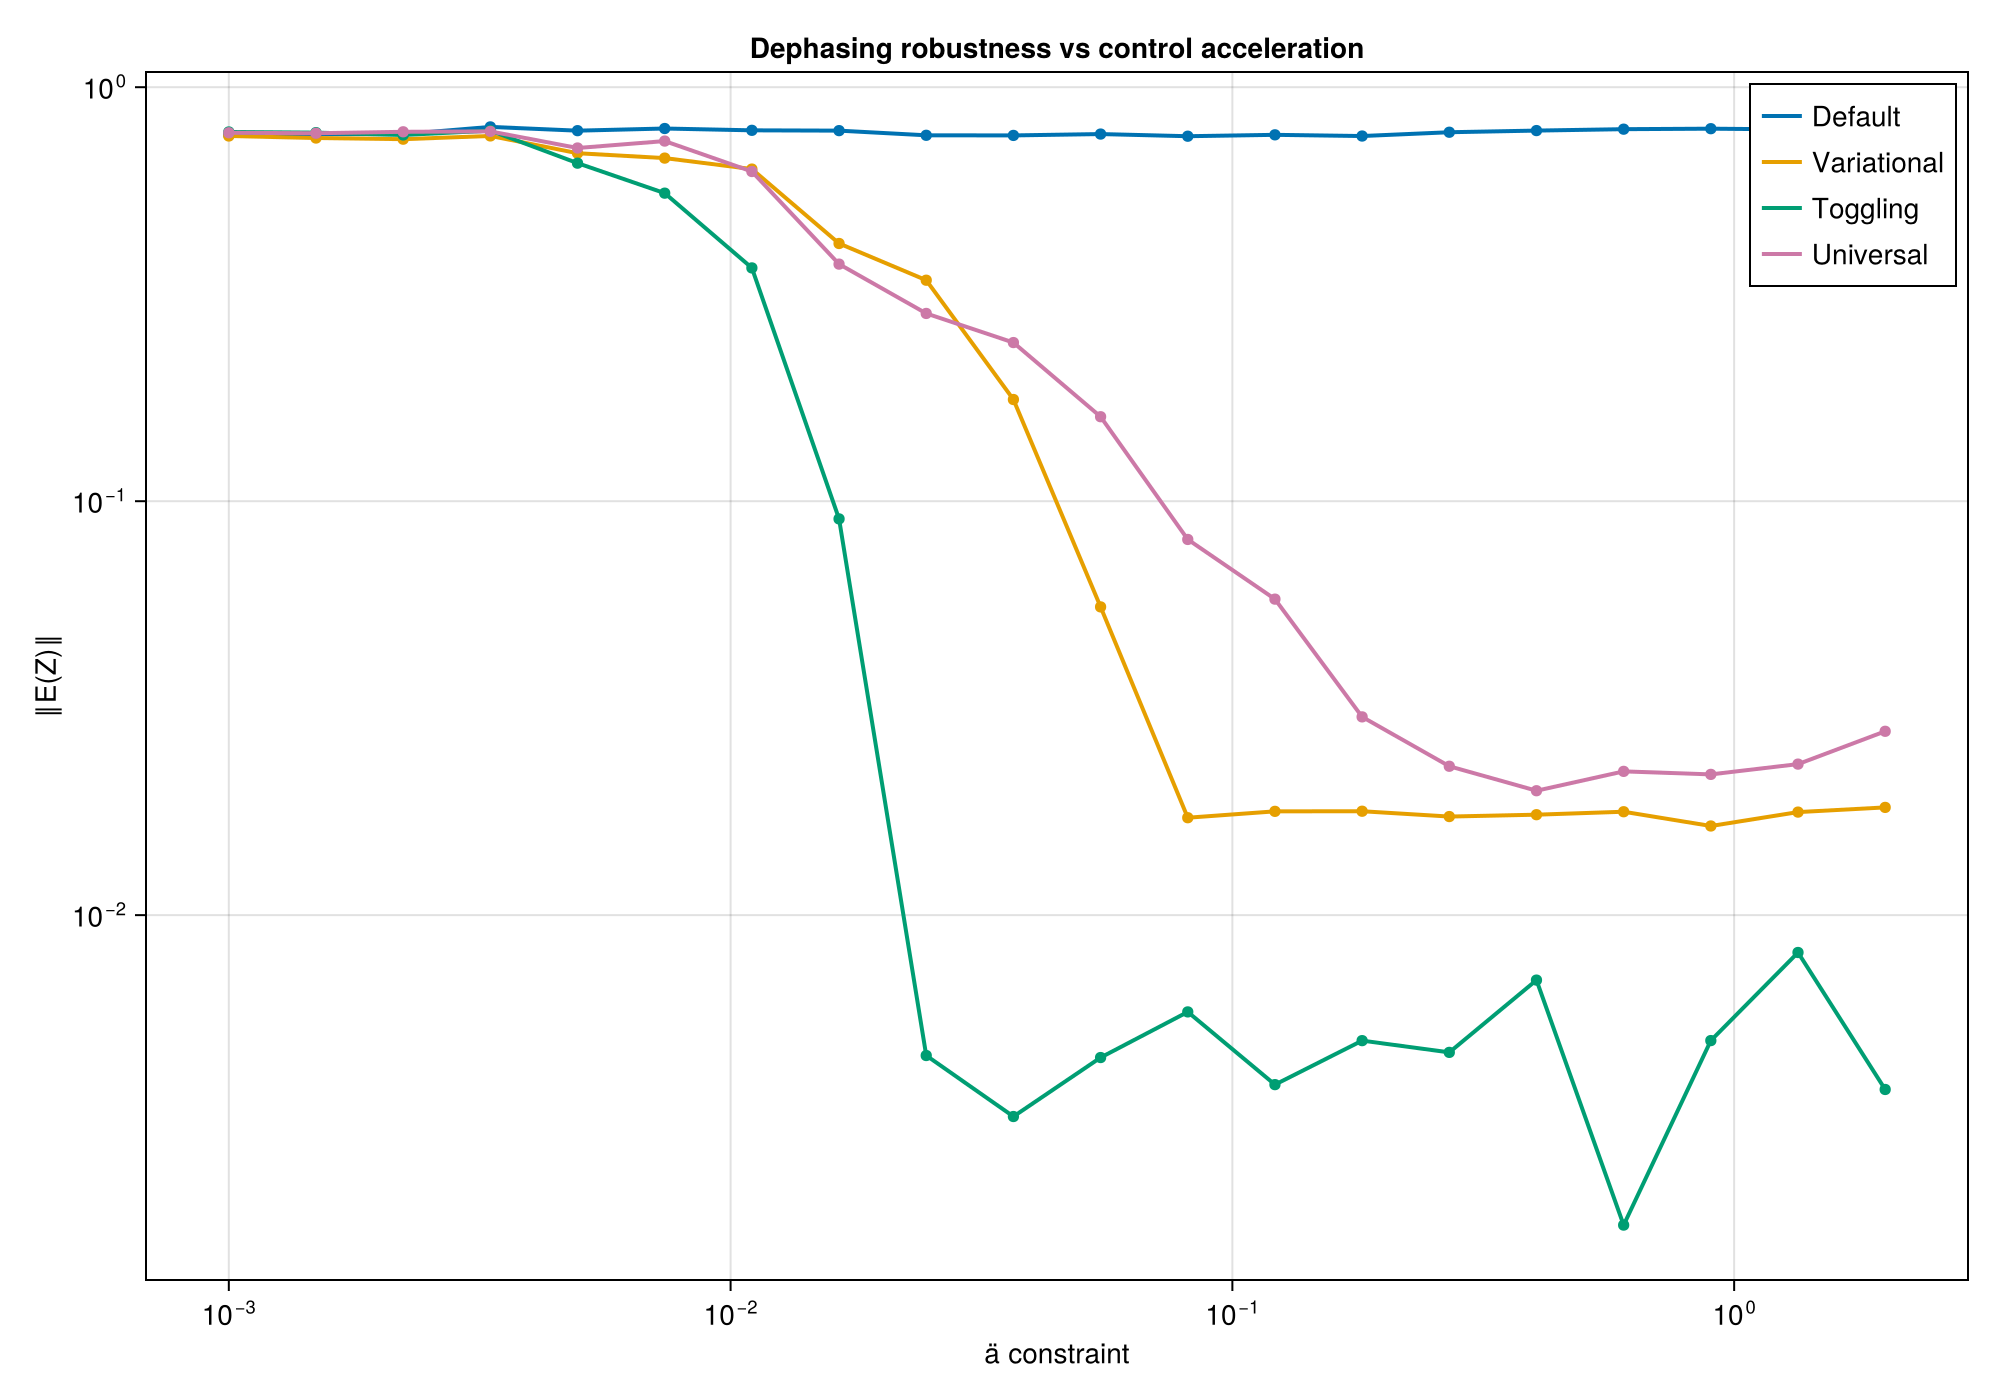

  Activating project at `~/Documents/GitHub/robust_control_sam/src`


CairoMakie.Screen{IMAGE}


In [25]:
using Pkg
Pkg.activate(".")

using CSV, DataFrames, Statistics
using CairoMakie
const CM = CairoMakie

# ---------- Load data ----------
seed_range = 1:8
dfs = DataFrame[]
for i in seed_range
    fn = "dda_dephasing_study/acceleration_sweep_dephasing_seed_$(i).csv"
    isfile(fn) && push!(dfs, CSV.read(fn, DataFrame))
end
@assert !isempty(dfs) "No CSV files were loaded."

# x (assumed identical across files and strictly positive)
x = collect(dfs[1].ä_vals)
@assert all(isequal(x), (collect(df.ä_vals) for df in dfs))
@assert all(x .> 0)

# Stack a column across seeds into an (n_x × n_seeds) matrix
stackcol(sym) = reduce(hcat, (df[!, sym] for df in dfs))

Y_def = stackcol(:norm_G_def_z)
Y_var = stackcol(:norm_G_var_z)
Y_add = stackcol(:norm_G_add_z)
Y_uni = stackcol(:norm_G_uni_z)

# ---------- Arithmetic mean across seeds ----------
mean_def = mean(Y_def; dims=2)[:]
mean_var = mean(Y_var; dims=2)[:]
mean_add = mean(Y_add; dims=2)[:]
mean_uni = mean(Y_uni; dims=2)[:]

# ---------- Plot ----------
colors = Makie.wong_colors()
labels = ["Default", "Variational", "Toggling", "Universal"]

fig = CM.Figure(size = (1000, 700))
ax  = CM.Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "‖E(Z)‖",
    xscale = log10,
    yscale = log10,
    title  = "Dephasing robustness vs control acceleration",
)

function draw!(y, color, label)
    CM.lines!(ax, x, y; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x, y; color=color, marker=:circle, markersize=8)
end

draw!(mean_def, colors[1], labels[1])
draw!(mean_var, colors[2], labels[2])
draw!(mean_add, colors[3], labels[3])
draw!(mean_uni, colors[4], labels[4])

CM.axislegend(ax; position=:rt)
display(fig)
# save("dda_constraint_dephasing_z_means_linear.png", fig; px_per_unit=2)

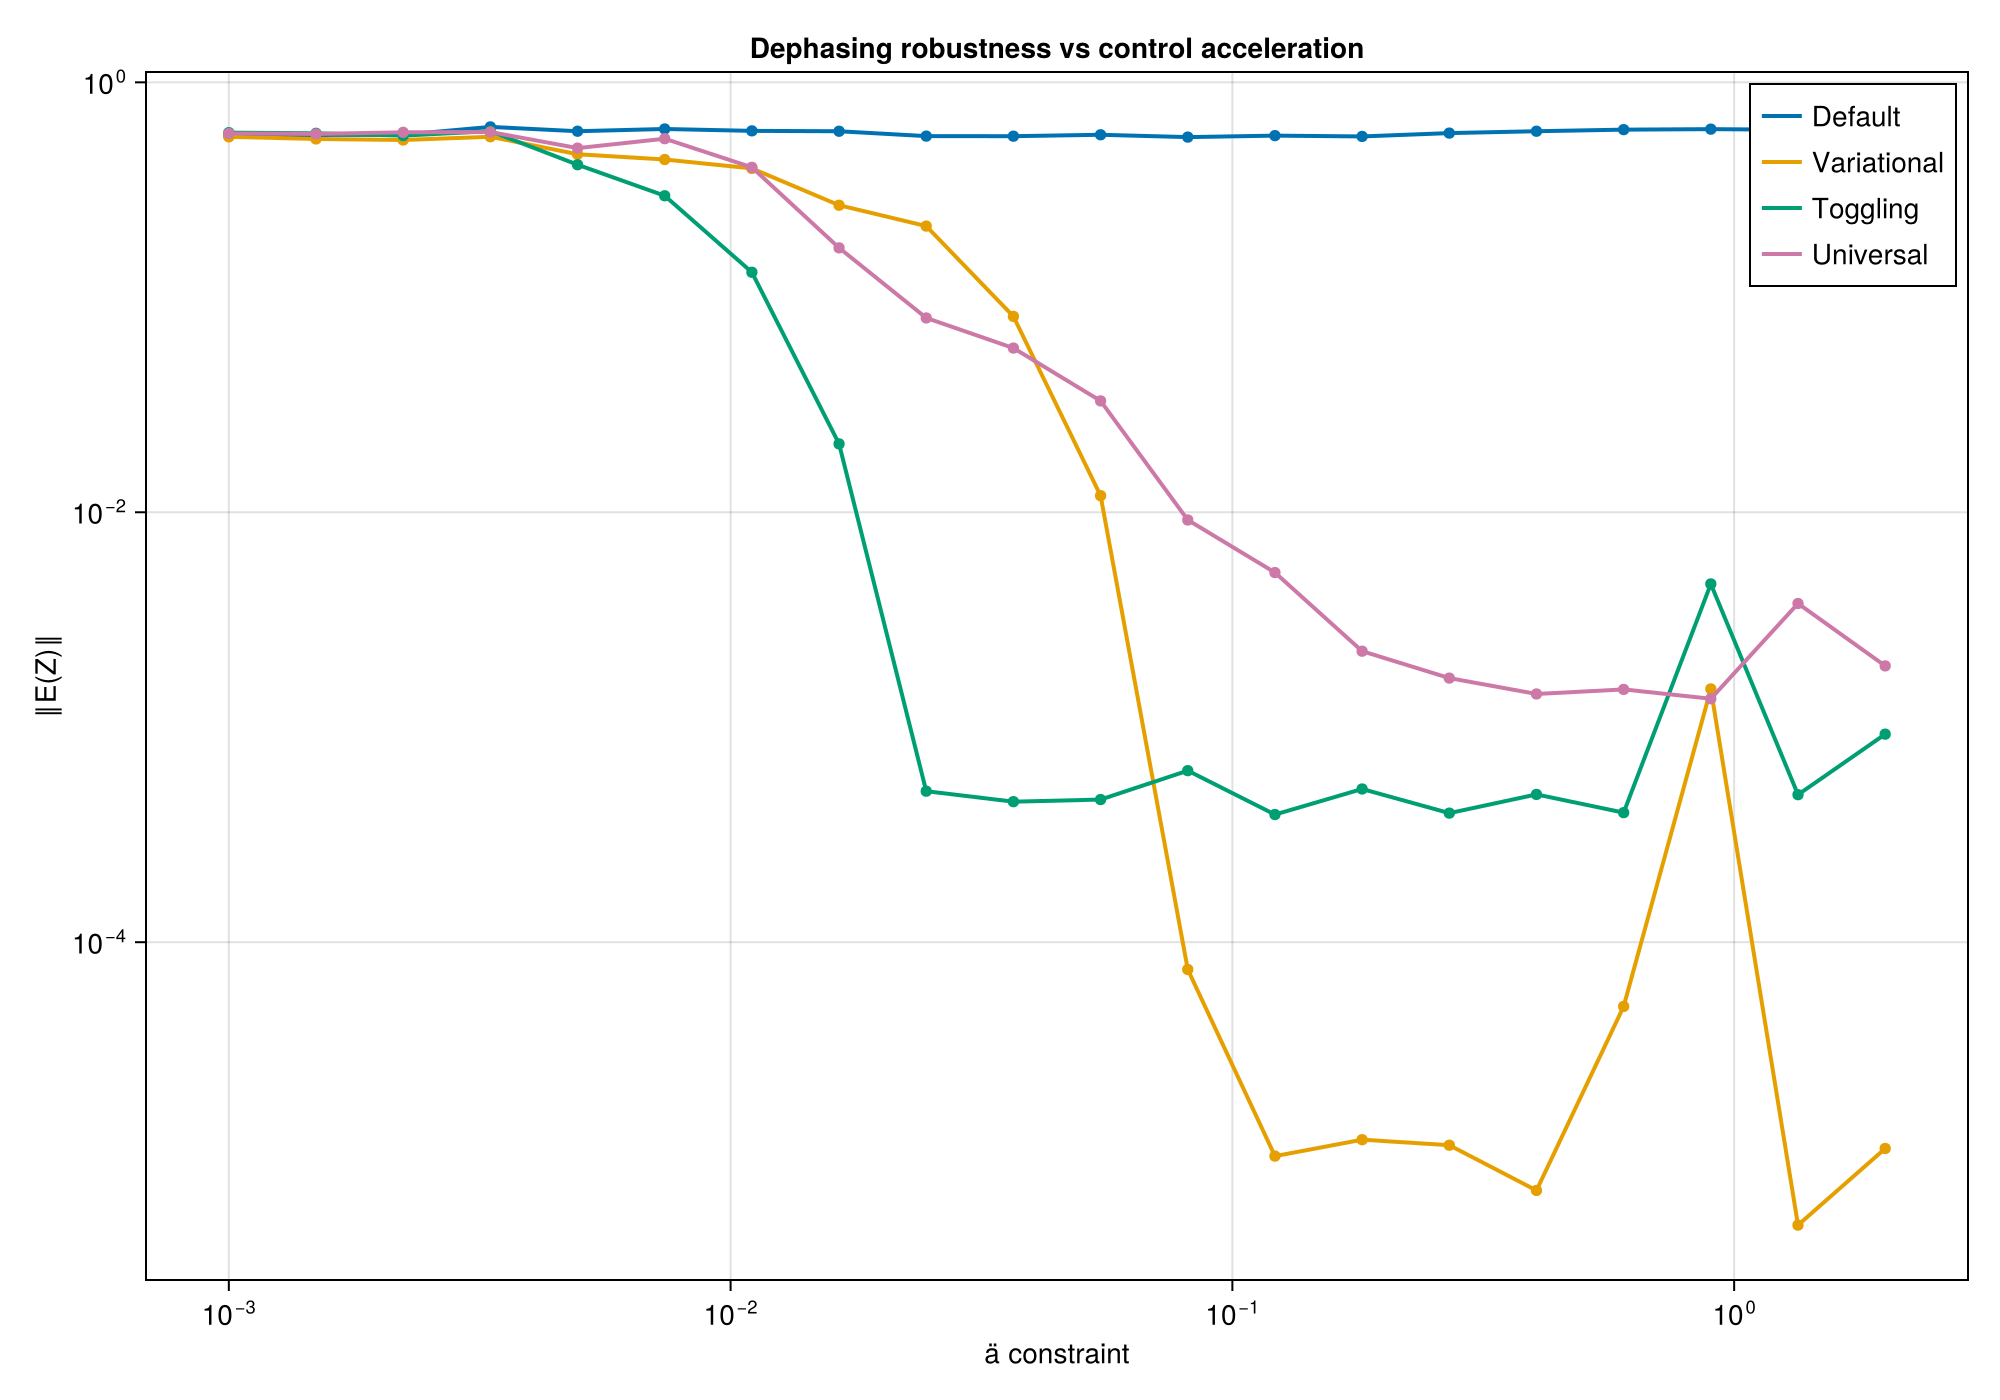

  Activating project at `~/Documents/GitHub/robust_control_sam/src`


CairoMakie.Screen{IMAGE}


In [24]:
using Pkg
Pkg.activate(".")

using CSV, DataFrames, Statistics
using CairoMakie
const CM = CairoMakie

# ---------- Load data ----------
seed_range = 1:8
dfs = DataFrame[]
for i in seed_range
    fn = "dda_dephasing_study/acceleration_sweep_dephasing_seed_$(i).csv"
    isfile(fn) && push!(dfs, CSV.read(fn, DataFrame))
end
@assert !isempty(dfs) "No CSV files were loaded."

# x (assumed identical across files and strictly positive)
x = collect(dfs[1].ä_vals)
@assert all(isequal(x), (collect(df.ä_vals) for df in dfs))
@assert all(x .> 0)

# Stack a column across seeds into an (n_x × n_seeds) matrix
stackcol(sym) = reduce(hcat, (df[!, sym] for df in dfs))

Y_def = stackcol(:var_obj_def_z)
Y_var = stackcol(:var_obj_var_z)
Y_add = stackcol(:var_obj_tog_z)
Y_uni = stackcol(:var_obj_uni_z)

# ---------- Arithmetic mean across seeds ----------
mean_def = mean(Y_def; dims=2)[:]
mean_var = mean(Y_var; dims=2)[:]
mean_add = mean(Y_add; dims=2)[:]
mean_uni = mean(Y_uni; dims=2)[:]

# ---------- Plot ----------
colors = Makie.wong_colors()
labels = ["Default", "Variational", "Toggling", "Universal"]

fig = CM.Figure(size = (1000, 700))
ax  = CM.Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "‖E(Z)‖",
    xscale = log10,
    yscale = log10,
    title  = "Dephasing robustness vs control acceleration",
)

function draw!(y, color, label)
    CM.lines!(ax, x, y; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x, y; color=color, marker=:circle, markersize=8)
end

draw!(mean_def, colors[1], labels[1])
draw!(mean_var, colors[2], labels[2])
draw!(mean_add, colors[3], labels[3])
draw!(mean_uni, colors[4], labels[4])

CM.axislegend(ax; position=:rt)
display(fig)
# save("dda_constraint_dephasing_z_means_linear.png", fig; px_per_unit=2)